In [1]:
# Import necessary libraries for data processing, modeling, and visualization.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from arch import arch_model
from MSMsource_Etienne import compute_MSM_vol

In [2]:
# Define functions for computing historical volatility and exponentially weighted moving average (EWMA) volatility.

#volatility formulas
def historical_volatility(returns, window=30):
    return returns.rolling(window=window).std() 
def ewma_volatility(returns, span=30):
    return returns.ewm(span=span).std() # Exponentially weighted moving average

In [ ]:
# Load BTC-USD price data, compute log-returns, and apply volatility estimation models (historical, EWMA, MSM, GARCH).

data_file = "BTC-USD.csv"  # à remplacer 
start_date='2014-01-01'
end_date='2025-03-09'


data = pd.read_csv(data_file, parse_dates=["Date"], index_col="Date")
data.columns = data.columns.str.strip()
data = data.loc[start_date:end_date]  
data["Returns"] = np.log(data["Price"] / data["Price"].shift(1))
data = data.dropna()  

historical_vol = historical_volatility(data["Returns"])
ewma_vol = ewma_volatility(data["Returns"])

start_date = data.index[30] 
historical_vol = historical_vol[start_date:]
ewma_vol = ewma_vol[start_date:]


# MSM vol
data_real = data['Returns'].values[:, np.newaxis]
data_real = data_real[1:]
msm_fit = compute_MSM_vol(data_real)
msm_fit_volatility = msm_fit[0]

# Fit a GARCH(1, 1) model
garch_model = arch_model(data['Returns'], vol='Garch', p=1, q=1)
garch_fit = garch_model.fit(disp="off")  
# misalignment of Garch by 1 day
garch_fit_volatility_shifted = np.roll(garch_fit.conditional_volatility, -1)
garch_fit_volatility_shifted[-1:] = np.nan  


data, msm_fit_volatility, garch_fit_volatility_shifted, historical_vol, ewma_vol

[4.20833365 1.54733177 0.99930257 0.04283178]


(                 Price   Returns
 Date                            
 2014-01-03  807.222939  0.027974
 2014-01-04  828.602063  0.026140
 2014-01-05  902.487380  0.085415
 2014-01-06  914.459961  0.013179
 2014-01-07  803.351796 -0.129541
 ...                ...       ...
 2015-03-05  276.268809  0.010265
 2015-03-06  273.318115 -0.010738
 2015-03-07  276.403357  0.011225
 2015-03-08  275.338034 -0.003862
 2015-03-09  290.130059  0.052330
 
 [431 rows x 2 columns],
 array([0.04283178, 0.03909079, 0.06130996, 0.04098325, 0.07562172,
        0.04982982, 0.04111133, 0.04230558, 0.0482802 , 0.0536969 ,
        0.04618099, 0.03725357, 0.04225777, 0.04289295, 0.04242895,
        0.03914105, 0.04359919, 0.03513452, 0.02993391, 0.02655649,
        0.02563978, 0.03642579, 0.03679523, 0.03068827, 0.05678475,
        0.05621607, 0.0372194 , 0.03159125, 0.0269871 , 0.0269163 ,
        0.02248214, 0.02232147, 0.02137967, 0.02559064, 0.03009847,
        0.04707489, 0.0467398 , 0.0350755 , 0.02780449,

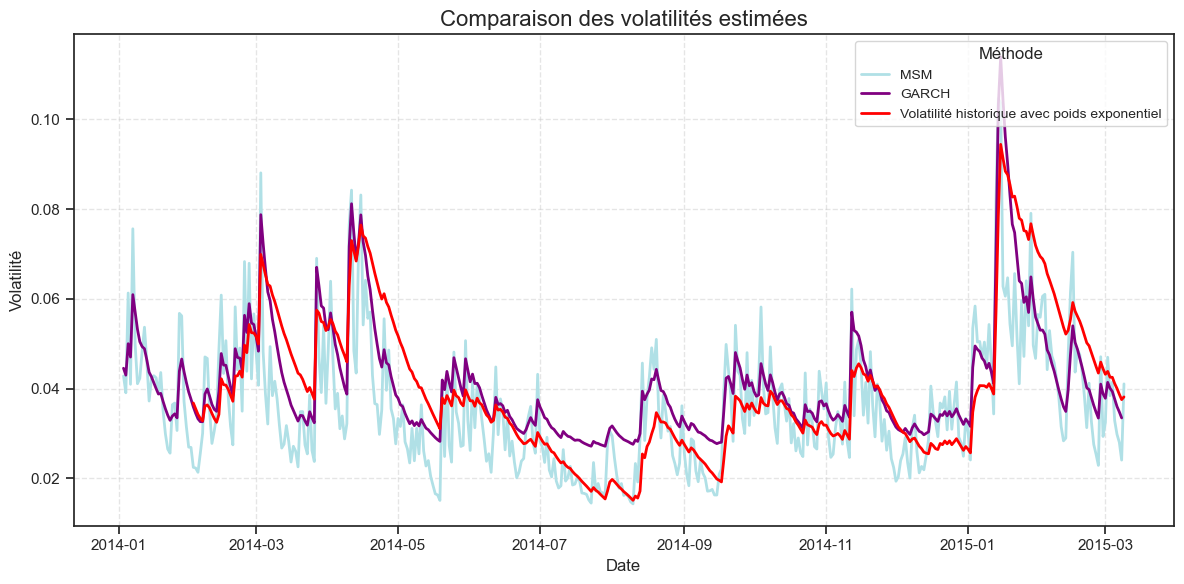

In [4]:
# Plot and compare volatilities estimated using MSM, GARCH, and EWMA methods.

plt.figure(figsize=(12, 6))  # Taille plus grande
# Tracer les séries de volatilité
plt.plot(data.index, msm_fit_volatility, label="MSM", color='powderblue', linestyle='-', linewidth=2)
plt.plot(data.index, garch_fit_volatility_shifted, label="GARCH", color='purple', linewidth=2)
#plt.plot(historical_vol.index, historical_vol, label="Historique", color='green', linestyle='--', linewidth=2)
plt.plot(ewma_vol.index, ewma_vol, label="Volatilité historique avec poids exponentiel", color='red', linewidth=2)
# Améliorations visuelles
plt.title("Comparaison des volatilités estimées", fontsize=16)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Volatilité", fontsize=12)
plt.grid(True, which='both', linestyle='--', alpha=0.5)
# Légende améliorée
plt.legend(title="Méthode", fontsize=10, title_fontsize=12, loc='upper right')
# Bordures propres
plt.tight_layout()
plt.savefig('volatility_comparison_'+str(start_date)+'_'+str(end_date)+'.png', dpi=300, bbox_inches='tight')  
plt.show()

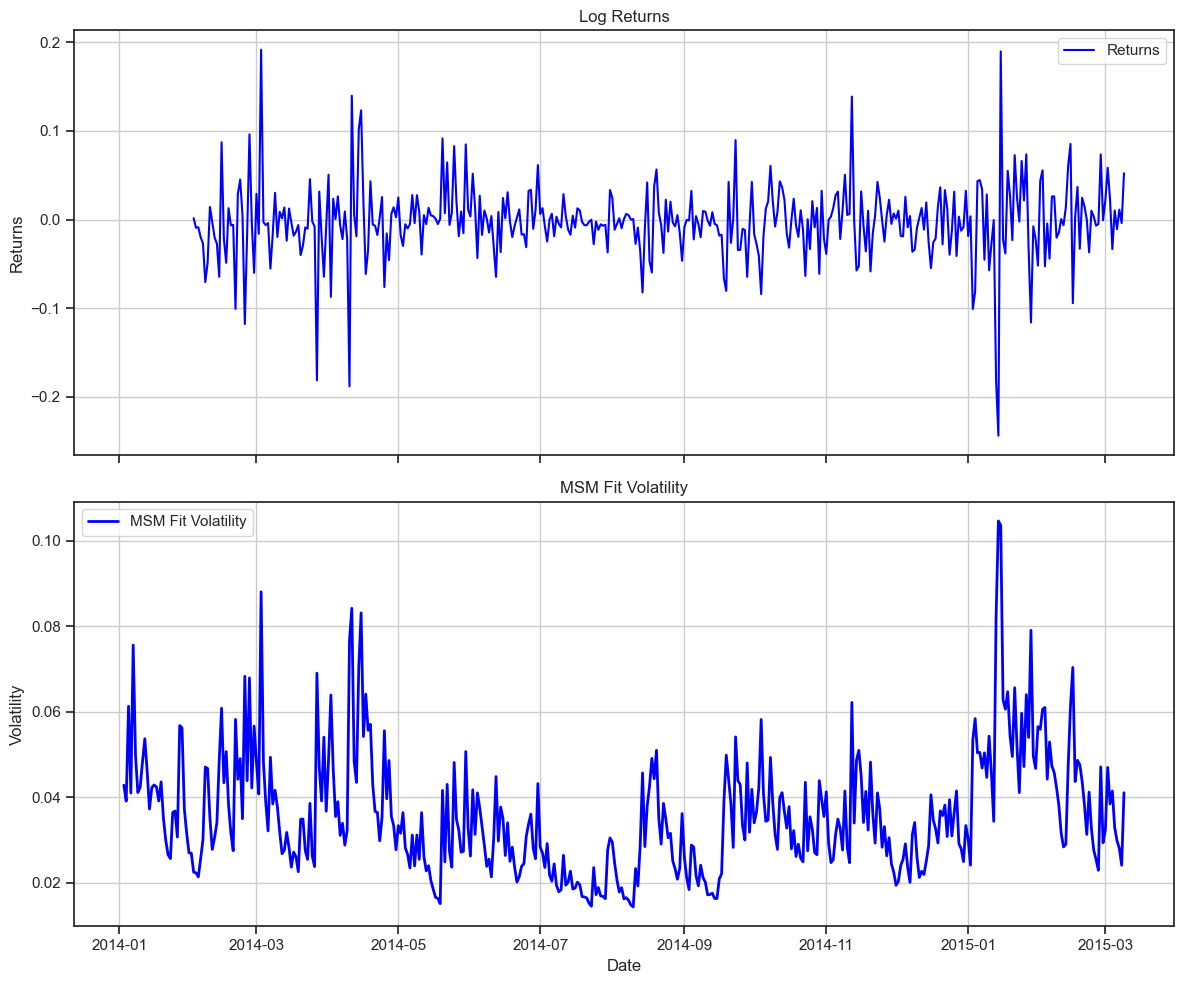

In [5]:
# Plot log returns and corresponding volatility estimated by the MSM model.

# Plot the log returns and the MSM fit volatility
fig, axs = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Plot returns
axs[0].plot(data.loc[start_date:].index, data.loc[start_date:, "Returns"], label="Returns", color='blue')
#axs[0].plot(data.index, msm_fit_volatility, label="MSM Fit Volatility", color='skyblue', linestyle='-', linewidth=2)

axs[0].set_title('Log Returns')
axs[0].set_ylabel('Returns')
axs[0].legend(loc="best")
axs[0].grid(True)

axs[1].plot(data.index, msm_fit_volatility, label="MSM Fit Volatility", color='blue', linestyle='-', linewidth=2)
axs[1].set_title('MSM Fit Volatility')
axs[1].set_xlabel('Date')
axs[1].set_ylabel('Volatility')
axs[1].legend(loc="best")
axs[1].grid(True)

# Adjust layout
plt.tight_layout()
plt.show()

In [6]:
# Création d'un DataFrame
df = pd.DataFrame({
    'Date': data.index,
    'Volatility': msm_fit_volatility
})
# Écriture dans un fichier CSV
df.to_csv('msm_df_output.csv', index=False)


In [ ]:
start_date='2018-01-01'
end_date='2025-03-09'

def PlotVol(data_file, start_date='2014-01-01', end_date='2015-03-09'):
    data = pd.read_csv(data_file, parse_dates=["Date"], index_col="Date")
    data = data.loc[start_date:end_date]  
    data["Returns"] = np.log(data["Price"] / data["Price"].shift(1))
    data = data.dropna()  

    historical_vol = historical_volatility(data["Returns"])
    ewma_vol = ewma_volatility(data["Returns"])

    start_date = data.index[30] 
    historical_vol = historical_vol[start_date:]
    ewma_vol = ewma_vol[start_date:]


    # MSM vol
    data_real = data['Returns'].values[:, np.newaxis]
    data_real = data_real[1:]
    msm_fit = compute_MSM_vol(data_real)
    msm_fit_volatility = msm_fit[0]

    # Fit a GARCH(1, 1) model
    garch_model = arch_model(data['Returns'], vol='Garch', p=1, q=1)
    garch_fit = garch_model.fit(disp="off")  
    # misalignment of Garch by 1 day
    garch_fit_volatility_shifted = np.roll(garch_fit.conditional_volatility, -1)
    garch_fit_volatility_shifted[-1:] = np.nan  


    data, msm_fit_volatility, garch_fit_volatility_shifted, historical_vol, ewma_vol
    plt.figure(figsize=(12, 6))  # Taille plus grande
    # Tracer les séries de volatilité
    plt.plot(data.index, msm_fit_volatility, label="MSM", color='powderblue', linestyle='-', linewidth=2)
    plt.plot(data.index, garch_fit_volatility_shifted, label="GARCH", color='purple', linewidth=2)
    #plt.plot(historical_vol.index, historical_vol, label="Historique", color='green', linestyle='--', linewidth=2)
    plt.plot(ewma_vol.index, ewma_vol, label="Volatilité historique avec poids exponentiel", color='red', linewidth=2)
    # Améliorations visuelles
    plt.title("Comparaison des volatilités estimées", fontsize=16)
    plt.xlabel("Date", fontsize=12)
    plt.ylabel("Volatilité", fontsize=12)
    plt.grid(True, which='both', linestyle='--', alpha=0.5)
    # Légende améliorée
    plt.legend(title="Méthode", fontsize=10, title_fontsize=12, loc='upper right')
    # Bordures propres
    plt.tight_layout()
    plt.savefig('volatility_comparison_'+str(start_date)+'_'+str(end_date)+'.png', dpi=300, bbox_inches='tight')  
    plt.show()

[30.00338476  1.81263825  0.47642719  0.05233683]


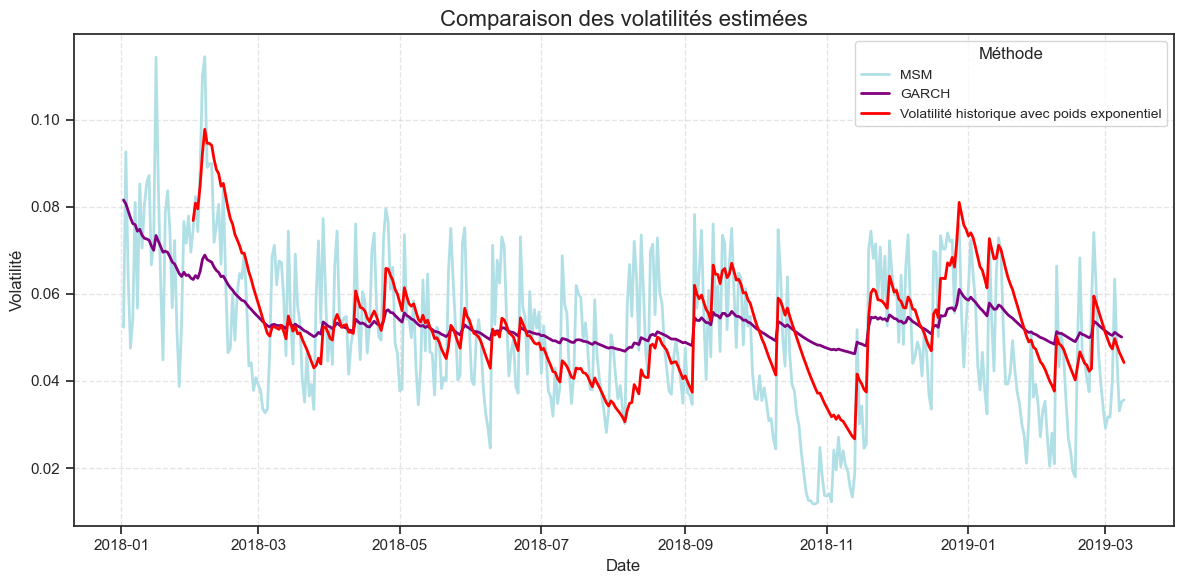

[1.001      1.42889806 0.04858779 0.00996171]


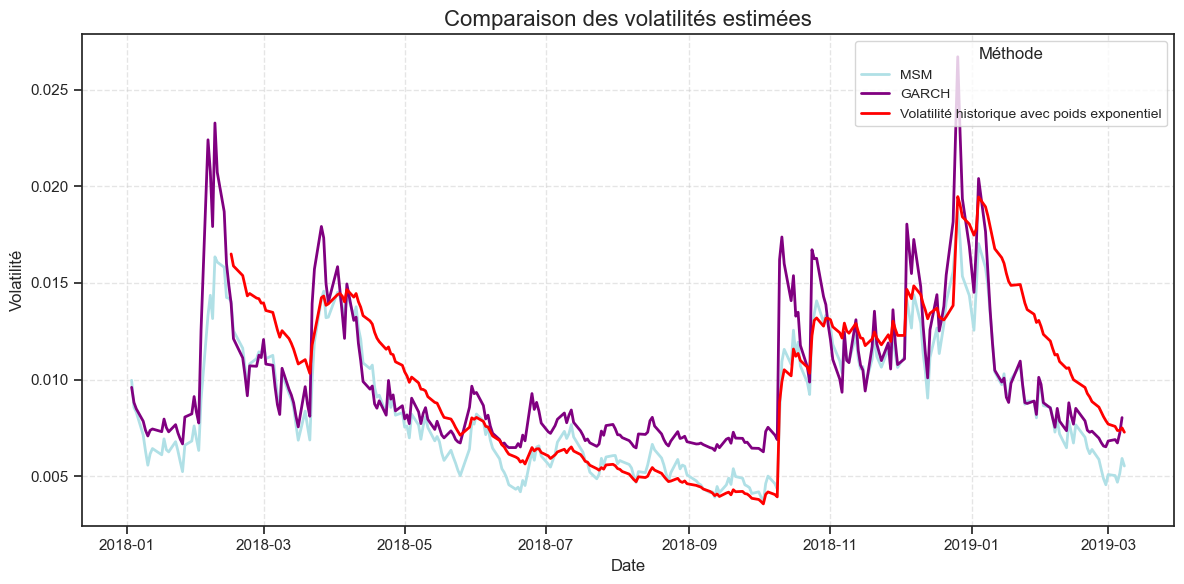

[4.99962207 1.65305191 0.04696456 0.03711803]


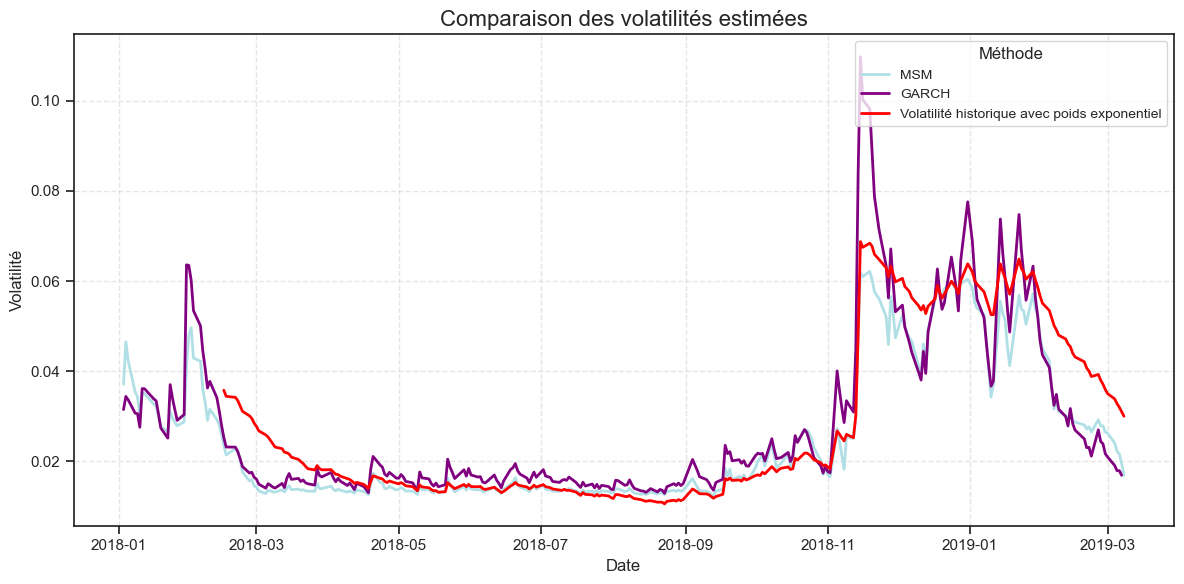

In [18]:
PlotVol('ETH-USD.csv', start_date, end_date)
PlotVol('SPY-USD.csv', start_date, end_date)
PlotVol('NG-USD.csv', start_date, end_date)